# Fitness App User Data - Clustering Analysis
## Data Cleaning and K-Means Clustering

In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# Load dataset
from google.colab import files
files.upload()
df = pd.read_excel('Fitness_App_User_Data.xlsx')

# Display first rows
df.head()

Saving Fitness_App_User_Data.xlsx to Fitness_App_User_Data.xlsx


,User_ID,Age,Gender,Workouts_per_Week,Avg_Session_Duration_Min,Steps_per_Day,Subscription_Type,Churned
0,1,56,Male,1,27.7,2055,Free,1
1,2,46,Female,6,68.6,10717,Free,0
2,3,32,Female,5,28.1,14761,Free,0
3,4,25,Male,6,64.2,14315,Free,0
4,5,38,Female,1,44.6,10150,Free,0


## Data Cleaning

In [3]:
# Check missing values
print('Missing Values:')
print(df.isnull().sum())

# Check duplicates
print('\nDuplicate Rows:', df.duplicated().sum())

# Data types
print('\nData Types:')
print(df.dtypes)

Missing Values:
User_ID                     0
Age                         0
Gender                      0
Workouts_per_Week           0
Avg_Session_Duration_Min    0
Steps_per_Day               0
Subscription_Type           0
Churned                     0
dtype: int64

Duplicate Rows: 0

Data Types:
User_ID                       int64
Age                           int64
Gender                       object
Workouts_per_Week             int64
Avg_Session_Duration_Min    float64
Steps_per_Day                 int64
Subscription_Type            object
Churned                       int64
dtype: object


## Feature Selection and Standardization

In [4]:
features = ['Age', 'Workouts_per_Week', 'Avg_Session_Duration_Min', 'Steps_per_Day']

X = df[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled[:5]

array([[ 1.37873744, -1.01131557, -1.0081477 , -1.70283492],
       [ 0.58338847,  1.49194079,  1.53397567,  0.55915421],
       [-0.53010009,  0.99128952, -0.98328586,  1.61520178],
       [-1.08684437,  1.49194079,  1.2604954 ,  1.49873362],
       [-0.05289071, -1.01131557,  0.04226513,  0.41108819]])

## Determine Optimal Number of Clusters

{2: np.float64(0.20334037491883644), 3: np.float64(0.20350583318358578), 4: np.float64(0.23254784134941264), 5: np.float64(0.23100850129565756), 6: np.float64(0.2276070557033803), 7: np.float64(0.22156890656748643)}


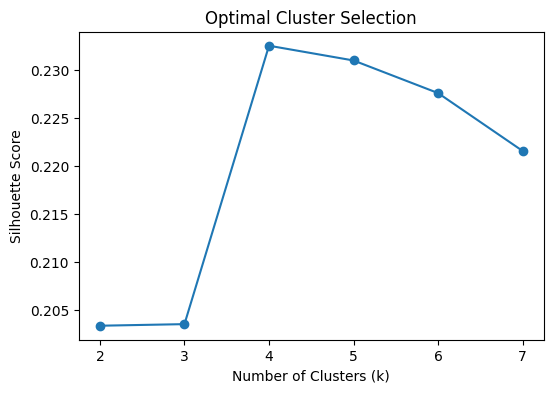

In [5]:
scores = {}

for k in range(2, 8):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    scores[k] = silhouette_score(X_scaled, labels)

print(scores)

plt.figure(figsize=(6,4))
plt.plot(list(scores.keys()), list(scores.values()), marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Optimal Cluster Selection')
plt.show()

## Apply K-Means Clustering

In [6]:
best_k = max(scores, key=scores.get)

kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

print('Optimal k =', best_k)
df.head()

Optimal k = 4


,User_ID,Age,Gender,Workouts_per_Week,Avg_Session_Duration_Min,Steps_per_Day,Subscription_Type,Churned,Cluster
0,1,56,Male,1,27.7,2055,Free,1,0
1,2,46,Female,6,68.6,10717,Free,0,2
2,3,32,Female,5,28.1,14761,Free,0,2
3,4,25,Male,6,64.2,14315,Free,0,2
4,5,38,Female,1,44.6,10150,Free,0,1


## Cluster Characteristics

In [7]:
cluster_summary = df.groupby('Cluster')[features].mean().round(2)
cluster_summary

,Age,Workouts_per_Week,Avg_Session_Duration_Min,Steps_per_Day
Cluster,,,,
0,32.73,2.13,46.14,4659.54
1,46.63,1.18,40.03,11247.37
2,28.41,4.61,51.58,11215.71
3,51.38,4.97,35.36,8065.43


## Cluster Visualization

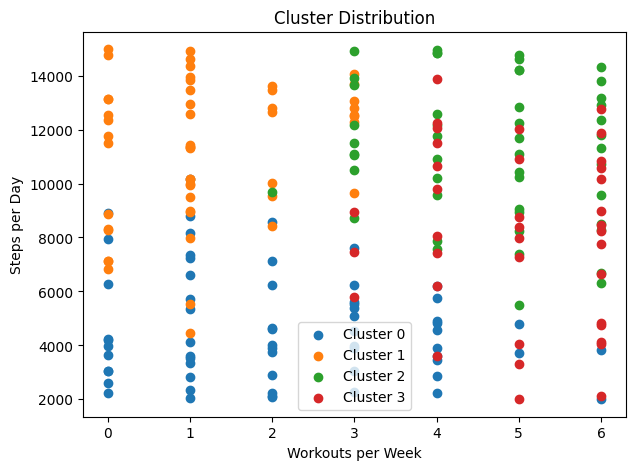

In [8]:
plt.figure(figsize=(7,5))

for cluster in sorted(df['Cluster'].unique()):
    subset = df[df['Cluster'] == cluster]
    plt.scatter(
        subset['Workouts_per_Week'],
        subset['Steps_per_Day'],
        label=f'Cluster {cluster}'
    )

plt.xlabel('Workouts per Week')
plt.ylabel('Steps per Day')
plt.title('Cluster Distribution')
plt.legend()
plt.show()